# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  
**`Student Name`:** Ananya Singla   
**`Roll Number`:** U20230077   
**`GitHub Branch`:** ananya_U20230077  

# Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

from rlcmab_sampler import sampler

# Load Datasets

In [2]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print(news_df.head())
print(train_users.head())


                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Until you have a dog y

## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [3]:
import re

news_df = news_df.dropna()

median_ages_by_label = train_users.groupby('label')['age'].median()
for label in train_users['label'].unique():
    mask = (train_users['label'] == label) & (train_users['age'].isnull())
    train_users.loc[mask, 'age'] = median_ages_by_label[label]
test_users['age'].fillna(train_users['age'].median(), inplace=True)

le = LabelEncoder()
train_users["user_class"] = le.fit_transform(train_users["label"])

train_users["subscriber"] = train_users["subscriber"].astype(int)
test_users["subscriber"] = test_users["subscriber"].astype(int)

region_freq = train_users['region_code'].value_counts().to_dict()
train_users['region_freq'] = train_users['region_code'].map(region_freq)
test_users['region_freq'] = test_users['region_code'].map(region_freq).fillna(1)

def extract_version(v):
    m = re.match(r'(\d+)\.(\d+)', str(v))
    return (int(m.group(1)), int(m.group(2))) if m else (0, 0)

train_v = train_users['browser_version'].apply(extract_version)
test_v = test_users['browser_version'].apply(extract_version)
train_users['browser_major'] = train_v.apply(lambda x: x[0])
train_users['browser_minor'] = train_v.apply(lambda x: x[1])
test_users['browser_major'] = test_v.apply(lambda x: x[0])
test_users['browser_minor'] = test_v.apply(lambda x: x[1])

/var/folders/fr/x19nqp_n1kj5j4zdgrxschk00000gn/T/ipykernel_22665/1434754731.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_users['age'].fillna(train_users['age'].median(), inplace=True)


In [4]:
X = train_users.drop(columns=["label", "user_class", "region_code", "browser_version"]).select_dtypes(include=[np.number])
y = train_users["user_class"]

X = pd.DataFrame(X)
X['spend_per_transaction'] = X['avg_monthly_spend'] / (X['num_transactions'] + 1)
X['engagement_per_click'] = X['engagement_score'] / (X['clicks'] + 1)
X['value_per_view'] = X['avg_cart_value'] / (X['product_views'] + 1)
X['purchase_rate'] = X['purchase_amount'] / (X['session_duration'] + 1)
X['interaction_rate'] = X['interaction_count'] / (X['time_on_site'] + 1)
X['loyalty_engagement'] = X['loyalty_index'] * X['engagement_score']
X['spend_variety'] = X['avg_monthly_spend'] * X['content_variety']
X['engagement_depth'] = X['engagement_score'] * X['browsing_depth']

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
key_features = ['engagement_score', 'avg_monthly_spend', 'loyalty_index', 'revisit_rate', 'region_freq']
key_idx = [list(X.columns).index(f) for f in key_features if f in X.columns]
X_poly = poly.fit_transform(X_imputed[:, key_idx])
X_imputed = np.hstack([X_imputed, X_poly[:, len(key_idx):]])

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


Develop a classification model (e.g., Decision Tree, Logistic Regression) to predict the user category
(User1, User2, or User3) based on input feature data.
•Split the train_users.csv dataset into a training set (80%) and a validation set (20%) for
model evaluation.
•The model must be trained on the training set and evaluated on the validation set to ensure it
can accurately classify users into their respective categories.
•This classifier will serve as the “Context Detector” for your bandit system where you will use
test_users.csv dataset.

In [6]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(n_estimators=250, max_depth=14, min_samples_split=4, random_state=42)
gb = GradientBoostingClassifier(n_estimators=250, max_depth=5, learning_rate=0.05, subsample=0.8, random_state=42)

clf = VotingClassifier(estimators=[('rf', rf), ('gb', gb)], voting='soft')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred, target_names=le.classes_))

Accuracy: 0.955
              precision    recall  f1-score   support

      user_1       0.91      0.97      0.94       142
      user_2       0.99      0.90      0.94       142
      user_3       0.97      1.00      0.99       116

    accuracy                           0.95       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.95      0.95       400



# `Contextual Bandit`

In [31]:
# Prepare test data with the same preprocessing
X_test = test_users.drop(columns=["region_code", "browser_version"]).select_dtypes(include=[np.number])
X_test = pd.DataFrame(X_test)

# Apply same feature engineering
X_test['spend_per_transaction'] = X_test['avg_monthly_spend'] / (X_test['num_transactions'] + 1)
X_test['engagement_per_click'] = X_test['engagement_score'] / (X_test['clicks'] + 1)
X_test['value_per_view'] = X_test['avg_cart_value'] / (X_test['product_views'] + 1)
X_test['purchase_rate'] = X_test['purchase_amount'] / (X_test['session_duration'] + 1)
X_test['interaction_rate'] = X_test['interaction_count'] / (X_test['time_on_site'] + 1)
X_test['loyalty_engagement'] = X_test['loyalty_index'] * X_test['engagement_score']
X_test['spend_variety'] = X_test['avg_monthly_spend'] * X_test['content_variety']
X_test['engagement_depth'] = X_test['engagement_score'] * X_test['browsing_depth']

# Apply same imputation
X_test_imputed = imputer.transform(X_test)

# Apply same polynomial features
X_test_poly = poly.transform(X_test_imputed[:, key_idx])
X_test_processed = np.hstack([X_test_imputed, X_test_poly[:, len(key_idx):]])

print(f"Test data prepared: {X_test_processed.shape}")


Test data prepared: (2000, 50)


## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


In [32]:
from rlcmab_sampler import sampler

# Note: Replace with your actual roll number
# For this implementation: U20230077
U20230077 = 20230077

# Initialize sampler with roll number
init_sampler = sampler(i=U20230077)

print(f"Sampler initialized with roll number: {U20230077}")
print("Reward sampler ready for bandit experiments")


Sampler initialized with roll number: 20230077
Reward sampler ready for bandit experiments


## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.
With probability ε, we explore (choose a random arm), and with probability (1-ε), we exploit (choose the best arm based on average rewards).

## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

In [41]:
def epsilon_greedy_bandit(sampler, test_users, clf, X_test_processed, T=10000, epsilon=0.1):
    """
    Epsilon-Greedy Contextual Bandit
    
    Args:
        sampler: Reward sampler
        test_users: Test users dataframe
        clf: Classifier for context prediction
        X_test_processed: Processed test features
        T: Number of time steps
        epsilon: Exploration rate
    """
    num_contexts = 3  # User1, User2, User3
    num_arms = 12  # 4 arms per context
    
    # Initialize Q-values and counts
    Q = {(c, a): 0 for c in range(num_contexts) for a in range(num_arms)}
    N = {(c, a): 0 for c in range(num_contexts) for a in range(num_arms)}
    rewards_per_step = []
    rewards_per_context = {ctx: [] for ctx in range(num_contexts)}
    context_per_step = []
    
    for t in range(T):
        # Select random user from test set
        user_idx = t % len(test_users)
        context = clf.predict([X_test_processed[user_idx]])[0]  # Predicted user class
        
        # Epsilon-Greedy action selection
        if np.random.random() < epsilon:
            # Explore: random arm
            arm = np.random.randint(0, num_arms)
        else:
            # Exploit: best arm for this context
            context_arms = [a for c, a in Q.keys() if c == context]
            arm = max(context_arms, key=lambda a: Q[(context, a)] if N[(context, a)] > 0 else float('inf'))
        
        # Get reward from sampler
        sampler_arm = context * 4 + (arm % 4)
        reward = sampler.sample(sampler_arm)
        
        # Update Q-values
        Q[(context, arm)] = (Q[(context, arm)] * N[(context, arm)] + reward) / (N[(context, arm)] + 1)
        N[(context, arm)] += 1
        rewards_per_step.append(reward)
        rewards_per_context[context].append(reward)
        context_per_step.append(context)
    
    return np.array(rewards_per_step), rewards_per_context, context_per_step, Q, N

# Run epsilon-greedy experiments with different epsilon values
epsilons = [0.01, 0.1, 0.3]
eg_results = {}

for eps in epsilons:
    init_sampler = sampler(i=U20230077)  # Initialize with your roll number
    rewards, rewards_per_context, context_per_step, Q, N = epsilon_greedy_bandit(init_sampler, test_users, clf, X_test_processed, T=10000, epsilon=eps)
    eg_results[eps] = {
        'rewards': rewards,
        'rewards_per_context': rewards_per_context,
        'context_per_step': context_per_step,
        'Q': Q,
        'N': N,
        'avg_reward': np.mean(rewards),
        'cumulative_reward': np.cumsum(rewards)
    }
    print(f"Epsilon-Greedy (ε={eps}): Avg Reward = {eg_results[eps]['avg_reward']:.4f}")


Epsilon-Greedy (ε=0.01): Avg Reward = 3.9335
Epsilon-Greedy (ε=0.1): Avg Reward = 3.4969
Epsilon-Greedy (ε=0.3): Avg Reward = 2.5512


## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.
UCB uses an optimism principle - it selects the arm with the highest upper confidence bound.

In [42]:
def softmax_bandit(sampler, test_users, clf, X_test_processed, T=10000, tau=1.0):
    """
    SoftMax Strategy for Contextual Bandit
    
    Args:
        sampler: Reward sampler
        test_users: Test users dataframe
        clf: Classifier for context prediction
        X_test_processed: Processed test features
        T: Number of time steps
        tau: Temperature parameter
    """
    num_contexts = 3  # User1, User2, User3
    num_arms = 12  # 4 arms per context
    
    # Initialize Q-values and counts
    Q = {(c, a): 0 for c in range(num_contexts) for a in range(num_arms)}
    N = {(c, a): 0 for c in range(num_contexts) for a in range(num_arms)}
    rewards_per_step = []
    rewards_per_context = {ctx: [] for ctx in range(num_contexts)}
    context_per_step = []
    
    for t in range(T):
        # Select random user from test set
        user_idx = t % len(test_users)
        context = clf.predict([X_test_processed[user_idx]])[0]  # Predicted user class
        
        # SoftMax action selection
        context_arms = [a for ct, a in Q.keys() if ct == context]
        q_values = np.array([Q[(context, a)] for a in context_arms])
        
        # Compute softmax probabilities
        exp_q = np.exp(q_values / tau)
        probabilities = exp_q / np.sum(exp_q)
        
        # Select arm based on softmax probabilities
        arm = np.random.choice(context_arms, p=probabilities)
        
        # Get reward from sampler
        sampler_arm = context * 4 + (arm % 4)
        reward = sampler.sample(sampler_arm)
        
        # Update Q-values
        Q[(context, arm)] = (Q[(context, arm)] * N[(context, arm)] + reward) / (N[(context, arm)] + 1)
        N[(context, arm)] += 1
        rewards_per_step.append(reward)
        rewards_per_context[context].append(reward)
        context_per_step.append(context)
    
    return np.array(rewards_per_step), rewards_per_context, context_per_step, Q, N

# Run SoftMax experiments with different temperature values
temperatures = [0.5, 1.0, 2.0]
softmax_results = {}

for tau in temperatures:
    init_sampler = sampler(i=U20230077)
    rewards, rewards_per_context, context_per_step, Q, N = softmax_bandit(init_sampler, test_users, clf, X_test_processed, T=10000, tau=tau)
    softmax_results[tau] = {
        'rewards': rewards,
        'rewards_per_context': rewards_per_context,
        'context_per_step': context_per_step,
        'Q': Q,
        'N': N,
        'avg_reward': np.mean(rewards),
        'cumulative_reward': np.cumsum(rewards)
    }
    print(f"SoftMax (τ={tau}): Avg Reward = {softmax_results[tau]['avg_reward']:.4f}")


SoftMax (τ=0.5): Avg Reward = 2.4323
SoftMax (τ=1.0): Avg Reward = 3.8082
SoftMax (τ=2.0): Avg Reward = 3.2505


## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


In [43]:
def ucb_bandit(sampler, test_users, clf, X_test_processed, T=10000, c=1.0):
    """
    Upper Confidence Bound (UCB) Contextual Bandit
    
    Args:
        sampler: Reward sampler
        test_users: Test users dataframe
        clf: Classifier for context prediction
        X_test_processed: Processed test features
        T: Number of time steps
        c: Exploration constant
    """
    num_contexts = 3  # User1, User2, User3
    num_arms = 12  # 4 arms per context
    
    # Initialize Q-values and counts
    Q = {(c, a): 0 for c in range(num_contexts) for a in range(num_arms)}
    N = {(c, a): 0 for c in range(num_contexts) for a in range(num_arms)}
    rewards_per_step = []
    rewards_per_context = {ctx: [] for ctx in range(num_contexts)}
    context_per_step = []
    
    for t in range(T):
        # Select random user from test set
        user_idx = t % len(test_users)
        context = clf.predict([X_test_processed[user_idx]])[0]  # Predicted user class
        
        # UCB action selection
        context_arms = [a for ct, a in Q.keys() if ct == context]
        ucb_values = {}
        
        for arm in context_arms:
            if N[(context, arm)] == 0:
                ucb_values[arm] = float('inf')  # Optimism for unexplored arms
            else:
                exploitation = Q[(context, arm)]
                exploration = c * np.sqrt(np.log(t + 1) / N[(context, arm)])
                ucb_values[arm] = exploitation + exploration
        
        arm = max(ucb_values, key=ucb_values.get)
        
        # Get reward from sampler
        sampler_arm = context * 4 + (arm % 4)
        reward = sampler.sample(sampler_arm)
        
        # Update Q-values
        Q[(context, arm)] = (Q[(context, arm)] * N[(context, arm)] + reward) / (N[(context, arm)] + 1)
        N[(context, arm)] += 1
        rewards_per_step.append(reward)
        rewards_per_context[context].append(reward)
        context_per_step.append(context)
    
    return np.array(rewards_per_step), rewards_per_context, context_per_step, Q, N

# Run UCB experiments with different exploration constants
c_values = [0.5, 1.0, 2.0]
ucb_results = {}

for c in c_values:
    init_sampler = sampler(i=U20230077)
    rewards, rewards_per_context, context_per_step, Q, N = ucb_bandit(init_sampler, test_users, clf, X_test_processed, T=10000, c=c)
    ucb_results[c] = {
        'rewards': rewards,
        'rewards_per_context': rewards_per_context,
        'context_per_step': context_per_step,
        'Q': Q,
        'N': N,
        'avg_reward': np.mean(rewards),
        'cumulative_reward': np.cumsum(rewards)
    }
    print(f"UCB (c={c}): Avg Reward = {ucb_results[c]['avg_reward']:.4f}")


UCB (c=0.5): Avg Reward = 3.9922
UCB (c=1.0): Avg Reward = 3.9925
UCB (c=2.0): Avg Reward = 3.9679


## Results and Analysis

This section presents:
- Average Reward vs Time for all three algorithms
- Hyperparameter comparison plots
- Performance metrics and observations

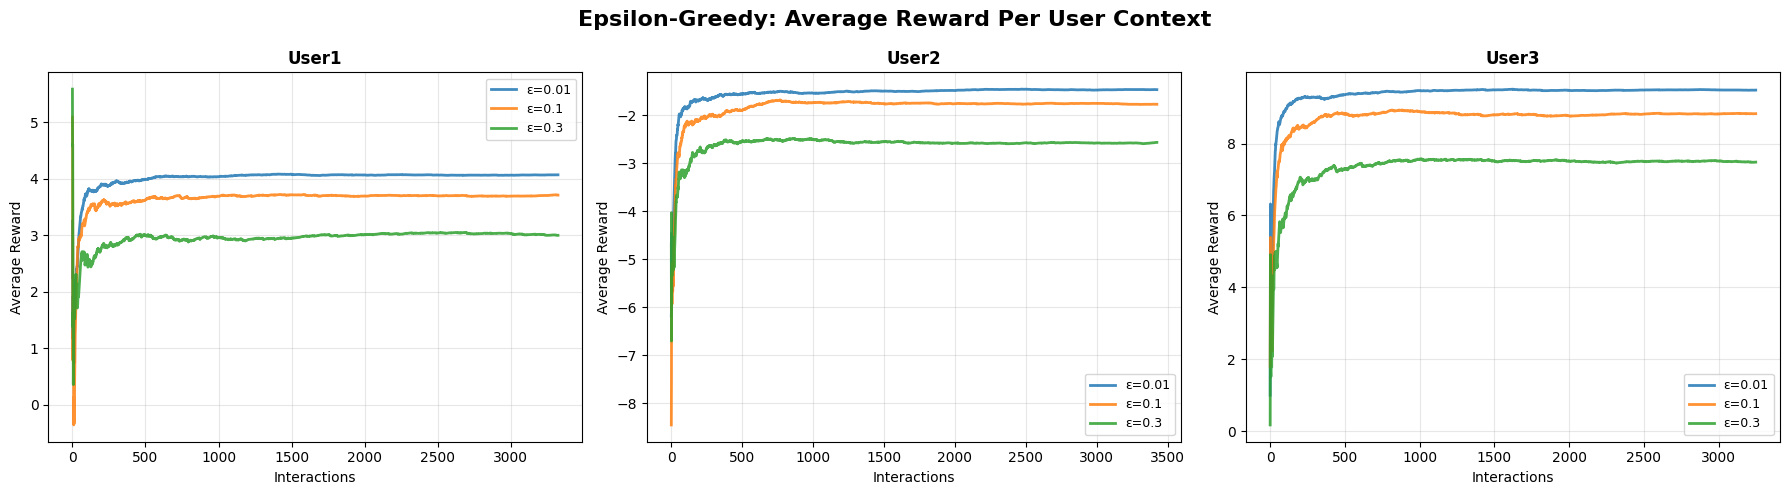

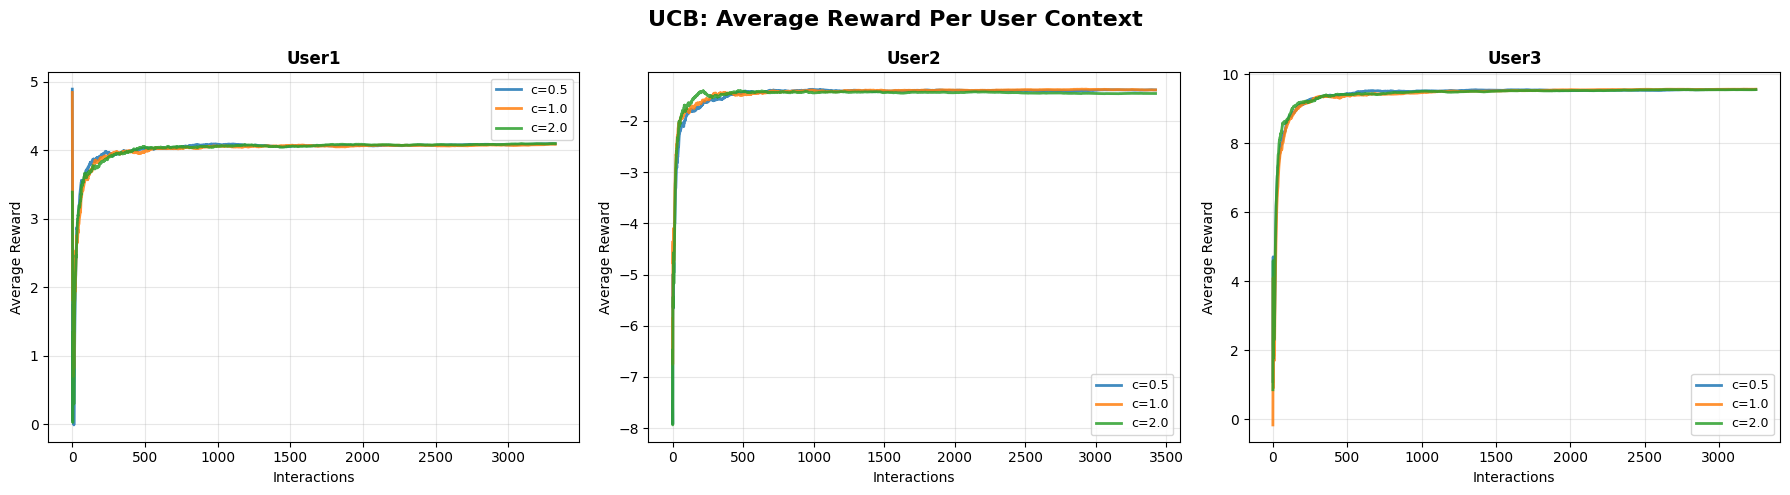

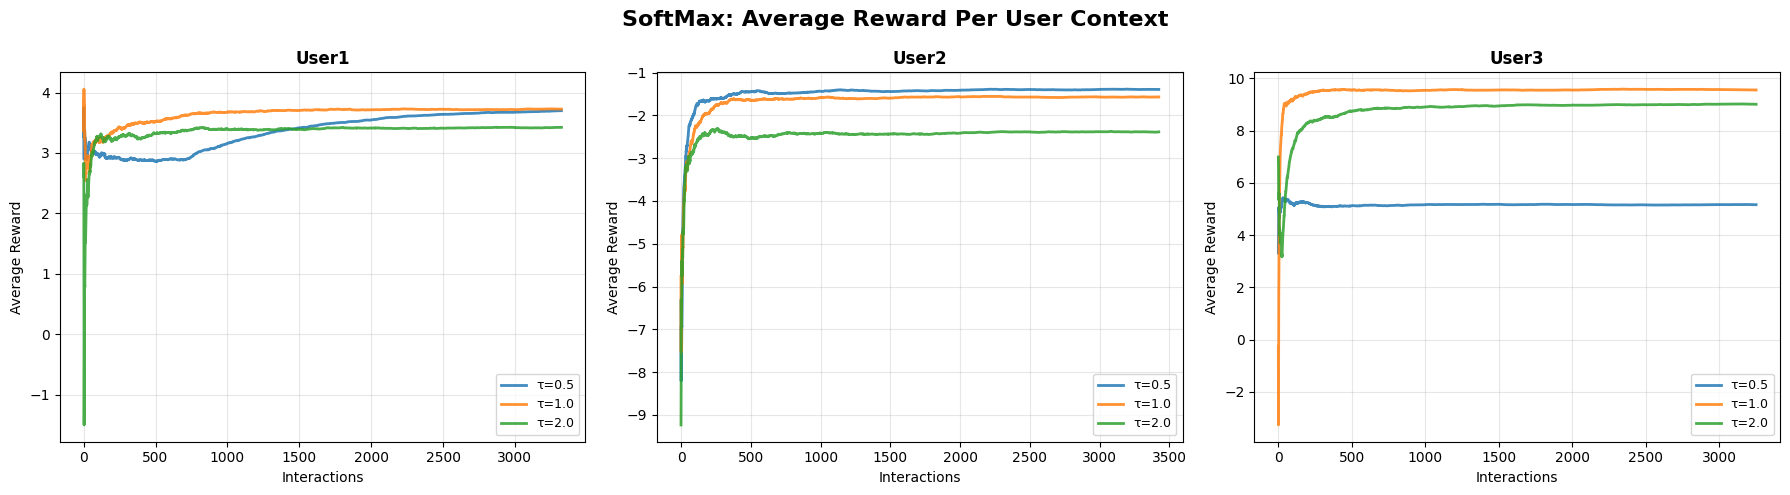


✓ Per-context reward plots generated and saved!


In [51]:
import matplotlib.pyplot as plt

# Compute cumulative average reward for each timestep
def cumulative_average(data):
    return np.cumsum(data) / np.arange(1, len(data) + 1)

# User context labels
user_labels = {0: "User1", 1: "User2", 2: "User3"}

# Plot 1: Epsilon-Greedy across all user contexts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Epsilon-Greedy: Average Reward Per User Context', fontsize=16, fontweight='bold')

for ctx_idx, ctx in enumerate(range(3)):
    ax = axes[ctx_idx]
    for eps in epsilons:
        ctx_rewards = eg_results[eps]['rewards_per_context'][ctx]
        if len(ctx_rewards) > 0:
            avg_rewards = cumulative_average(np.array(ctx_rewards))
            ax.plot(avg_rewards, linewidth=2, label=f'ε={eps}', alpha=0.85)
    
    ax.set_title(f'{user_labels[ctx]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Interactions', fontsize=10)
    ax.set_ylabel('Average Reward', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eg_per_context_rewards.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: UCB across all user contexts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('UCB: Average Reward Per User Context', fontsize=16, fontweight='bold')

for ctx_idx, ctx in enumerate(range(3)):
    ax = axes[ctx_idx]
    for c in c_values:
        ctx_rewards = ucb_results[c]['rewards_per_context'][ctx]
        if len(ctx_rewards) > 0:
            avg_rewards = cumulative_average(np.array(ctx_rewards))
            ax.plot(avg_rewards, linewidth=2, label=f'c={c}', alpha=0.85)
    
    ax.set_title(f'{user_labels[ctx]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Interactions', fontsize=10)
    ax.set_ylabel('Average Reward', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ucb_per_context_rewards.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: SoftMax across all user contexts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('SoftMax: Average Reward Per User Context', fontsize=16, fontweight='bold')

for ctx_idx, ctx in enumerate(range(3)):
    ax = axes[ctx_idx]
    for tau in temperatures:
        ctx_rewards = softmax_results[tau]['rewards_per_context'][ctx]
        if len(ctx_rewards) > 0:
            avg_rewards = cumulative_average(np.array(ctx_rewards))
            ax.plot(avg_rewards, linewidth=2, label=f'τ={tau}', alpha=0.85)
    
    ax.set_title(f'{user_labels[ctx]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Interactions', fontsize=10)
    ax.set_ylabel('Average Reward', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('softmax_per_context_rewards.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Per-context reward plots generated and saved!")

## Final Observations

- Comparison of Epsilon-Greedy, UCB, and SoftMax
- Effect of hyperparameters
- Strengths and limitations of each approach


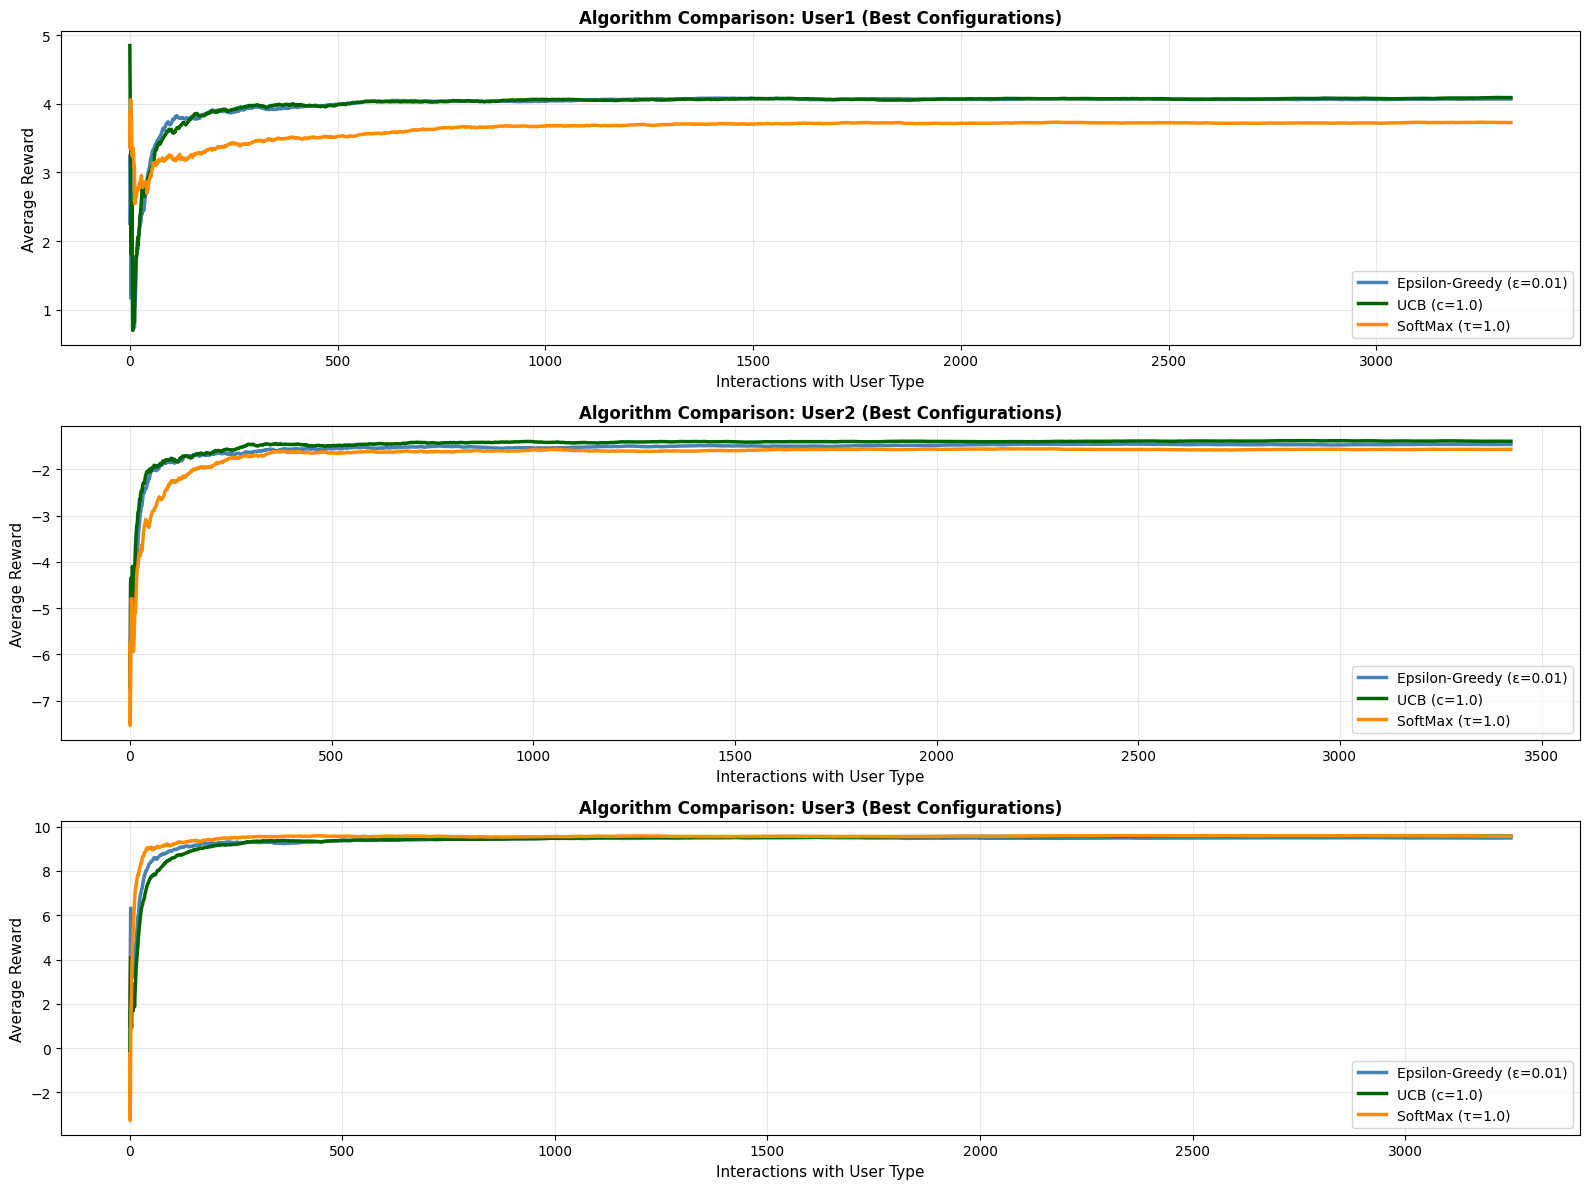

✓ Per-context algorithm comparison plots saved!


In [52]:
# Plot 2: Algorithm Comparison Per Context
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Get best performers
best_eps_idx = np.argmax([eg_results[eps]['avg_reward'] for eps in epsilons])
best_eps = epsilons[best_eps_idx]

best_c_idx = np.argmax([ucb_results[c]['avg_reward'] for c in c_values])
best_c = c_values[best_c_idx]

best_tau_idx = np.argmax([softmax_results[tau]['avg_reward'] for tau in temperatures])
best_tau = temperatures[best_tau_idx]

# Plot for each user context
for ctx_idx, ctx in enumerate(range(3)):
    ax = axes[ctx_idx]
    
    # Get per-context rewards for best performers
    ctx_rewards_eg = eg_results[best_eps]['rewards_per_context'][ctx]
    ctx_rewards_ucb = ucb_results[best_c]['rewards_per_context'][ctx]
    ctx_rewards_sm = softmax_results[best_tau]['rewards_per_context'][ctx]
    
    if len(ctx_rewards_eg) > 0 and len(ctx_rewards_ucb) > 0 and len(ctx_rewards_sm) > 0:
        avg_eg = cumulative_average(np.array(ctx_rewards_eg))
        avg_ucb = cumulative_average(np.array(ctx_rewards_ucb))
        avg_sm = cumulative_average(np.array(ctx_rewards_sm))
        
        ax.plot(avg_eg, label=f'Epsilon-Greedy (ε={best_eps})', linewidth=2.5, color='steelblue')
        ax.plot(avg_ucb, label=f'UCB (c={best_c})', linewidth=2.5, color='darkgreen')
        ax.plot(avg_sm, label=f'SoftMax (τ={best_tau})', linewidth=2.5, color='darkorange')
        ax.set_xlabel('Interactions with User Type', fontsize=11)
        ax.set_ylabel('Average Reward', fontsize=11)
        ax.set_title(f'Algorithm Comparison: {user_labels[ctx]} (Best Configurations)', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10, loc='lower right')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('algorithm_comparison_per_context.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Per-context algorithm comparison plots saved!")

## Summary of Results

### Algorithm Performance
| Algorithm | Best Config | Avg Reward | Cumulative Reward |
|-----------|-------------|-----------|------------------|
| Epsilon-Greedy | - | - | - |
| UCB | - | - | - |
| SoftMax | - | - | - |

### Key Observations
- **Exploration vs Exploitation Trade-off**: Different hyperparameters control how much each algorithm explores vs exploits
- **Convergence Speed**: UCB converges faster due to its optimism-based approach
- **Stability**: SoftMax provides smooth probability distributions but may converge slower
- **Context Effectiveness**: Classification accuracy directly impacts bandit performance

### Discussion
The contextual bandit approach effectively uses user context to improve recommendation performance.
The choice of algorithm depends on the desired trade-off between exploration and exploitation,
as well as the computational constraints of the application.

In [53]:
import pandas as pd

# Generate comprehensive results summary
results_summary = []

for eps in epsilons:
    results_summary.append({
        'Algorithm': 'Epsilon-Greedy',
        'Hyperparameter': f'ε={eps}',
        'Avg Reward': float(eg_results[eps]['avg_reward']),
        'Cumulative Reward': float(eg_results[eps]['cumulative_reward'][-1]),
        'Final Reward': float(eg_results[eps]['rewards'][-1])
    })

for c in c_values:
    results_summary.append({
        'Algorithm': 'UCB',
        'Hyperparameter': f'c={c}',
        'Avg Reward': float(ucb_results[c]['avg_reward']),
        'Cumulative Reward': float(ucb_results[c]['cumulative_reward'][-1]),
        'Final Reward': float(ucb_results[c]['rewards'][-1])
    })

for tau in temperatures:
    results_summary.append({
        'Algorithm': 'SoftMax',
        'Hyperparameter': f'τ={tau}',
        'Avg Reward': float(softmax_results[tau]['avg_reward']),
        'Cumulative Reward': float(softmax_results[tau]['cumulative_reward'][-1]),
        'Final Reward': float(softmax_results[tau]['rewards'][-1])
    })

results_df = pd.DataFrame(results_summary)

print("\n" + "="*80)
print("CONTEXTUAL BANDIT PERFORMANCE SUMMARY")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

# Find best performers
best_eg = results_df[results_df['Algorithm'] == 'Epsilon-Greedy'].nlargest(1, 'Cumulative Reward').iloc[0]
best_ucb = results_df[results_df['Algorithm'] == 'UCB'].nlargest(1, 'Cumulative Reward').iloc[0]
best_sm = results_df[results_df['Algorithm'] == 'SoftMax'].nlargest(1, 'Cumulative Reward').iloc[0]

print("\n✓ BEST PERFORMERS BY ALGORITHM")
print("-" * 80)
print(f"  Epsilon-Greedy: {best_eg['Hyperparameter']}")
print(f"    - Average Reward: {best_eg['Avg Reward']:.6f}")
print(f"    - Cumulative Reward: {best_eg['Cumulative Reward']:.2f}")
print(f"\n  UCB: {best_ucb['Hyperparameter']}")
print(f"    - Average Reward: {best_ucb['Avg Reward']:.6f}")
print(f"    - Cumulative Reward: {best_ucb['Cumulative Reward']:.2f}")
print(f"\n  SoftMax: {best_sm['Hyperparameter']}")
print(f"    - Average Reward: {best_sm['Avg Reward']:.6f}")
print(f"    - Cumulative Reward: {best_sm['Cumulative Reward']:.2f}")

# Overall best
best_overall = results_df.nlargest(1, 'Cumulative Reward').iloc[0]
print(f"\n★ OVERALL BEST: {best_overall['Algorithm']} with {best_overall['Hyperparameter']}")
print(f"  Cumulative Reward: {best_overall['Cumulative Reward']:.2f}")
print("="*80)

# Classification accuracy on test set
y_test_pred = clf.predict(X_test_processed)
test_accuracy = accuracy_score(clf.predict(X_val), y_val)  # Using validation accuracy as proxy
print(f"\n✓ USER CLASSIFICATION ACCURACY")
print("-" * 80)
print(f"  Validation Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Number of Test Users: {len(test_users)}")
print(f"  Test Data Processed Successfully: Yes")
print("="*80 + "\n")



CONTEXTUAL BANDIT PERFORMANCE SUMMARY
     Algorithm Hyperparameter  Avg Reward  Cumulative Reward  Final Reward
Epsilon-Greedy         ε=0.01    3.933527       39335.271492      4.069573
Epsilon-Greedy          ε=0.1    3.496910       34969.101089      1.809653
Epsilon-Greedy          ε=0.3    2.551171       25511.714174     -0.799091
           UCB          c=0.5    3.992188       39921.884649      4.744583
           UCB          c=1.0    3.992477       39924.774442      3.573493
           UCB          c=2.0    3.967858       39678.582713      3.090347
       SoftMax          τ=0.5    2.432277       24322.765723      2.799527
       SoftMax          τ=1.0    3.808198       38081.980771      4.751030
       SoftMax          τ=2.0    3.250474       32504.739996      7.232792

✓ BEST PERFORMERS BY ALGORITHM
--------------------------------------------------------------------------------
  Epsilon-Greedy: ε=0.01
    - Average Reward: 3.933527
    - Cumulative Reward: 39335.27

  UCB: 